In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("dataset_6.csv", encoding="utf-8-sig", dtype={"region_code": "string"})

df.head(10)

In [ ]:
my_crop = "баклажан"
sample = df.loc[df["crop"].eq(my_crop)].copy()
sample.head(10)

In [ ]:
my_crop = "баклажан"
sample = df.loc[df["crop"].eq(my_crop)].copy()

print("=" * 60)
print("CROP:", my_crop)
print("Raw rows for crop:", len(sample))
print("=" * 60)




print("\n--- MISSING VALUES ---")
print(sample.isna().sum())

print("=" * 60)



print("\n--- FULL DUPLICATES ---")
print(sample[sample.duplicated(keep=False)].to_string())

print("=" * 60)

print("\n--- KEY DUPLICATES (region_code + crop + year) ---")
key = ["region_code", "crop", "year"]
key_dups_rows = sample.duplicated(key)
print(sample[key_dups_rows == True].to_string())

print("=" * 60)

print("\n--- SUSPICIOUS VALUES ---")
for col in ["harvested_area_ha", "production_t", "farms_count"]:
    print(f"\n{col}")
    print("  negative:", (sample[col] < 0).sum())
    print("  zero:", (sample[col] == 0).sum())


print("\n")

# Decision: remove full duplicates (keep first occurrence)
sample = sample.drop_duplicates()
print("\nRows after removing full duplicates:", len(sample))

In [ ]:
sample["yield_t_per_ha"] = (sample["production_t"] / sample["harvested_area_ha"].where(sample["harvested_area_ha"] > 0))

In [ ]:
def describe_and_outliers(series, name):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]

    print(f"\n--- {name} ---")
    print(f"count: {s.count()}")
    print(f"mean: {s.mean():.4f}")
    print(f"median: {s.median():.4f}")
    print(f"min: {s.min():.4f}")
    print(f"max: {s.max():.4f}")
    print(f"std (ddof=1): {s.std(ddof=1):.4f}")
    print(f"Q1: {q1:.4f}")
    print(f"Q3: {q3:.4f}")
    print(f"IQR: {iqr:.4f}")
    print(f"1.5 IQR lower bound: {lower:.4f}")
    print(f"1.5 IQR upper bound: {upper:.4f}")
    print(f"outlier candidates count: {outliers.count()}")
    if outliers.count() > 0:
        print("outlier candidates:")
        print(outliers)
    return s

prod = describe_and_outliers(sample["production_t"], "Production, t")
yld = describe_and_outliers(sample["yield_t_per_ha"], "Yield, t/ha")

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(prod, bins=8, edgecolor="black")
plt.axvline(prod.mean(), color="red", linestyle="--", label=f"mean = {prod.mean():.2f}")
plt.axvline(prod.median(), color="green", linestyle="--", label=f"median = {prod.median():.2f}")
plt.title("Production histogram: баклажан")
plt.xlabel("Production, t")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

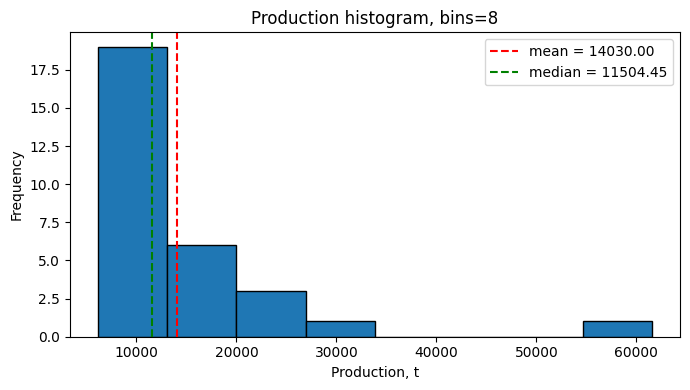

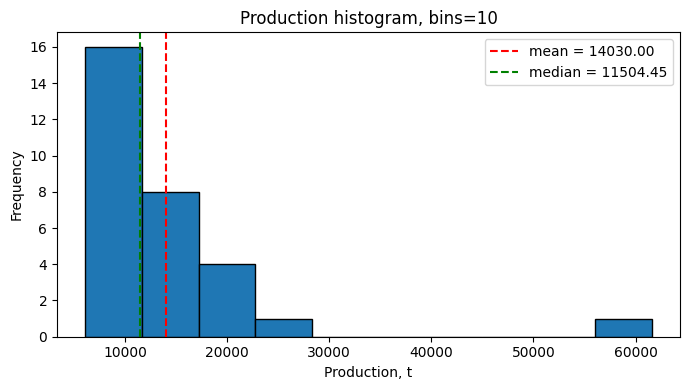

In [40]:
for bins in [6, 8, 10]:
    plt.figure(figsize=(7, 4))
    plt.hist(prod, bins=bins, edgecolor="black")
    plt.axvline(prod.mean(), color="red", linestyle="--", label=f"mean = {prod.mean():.2f}")
    plt.axvline(prod.median(), color="green", linestyle="--", label=f"median = {prod.median():.2f}")
    plt.title(f"Production histogram, bins={bins}")
    plt.xlabel("Production, t")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

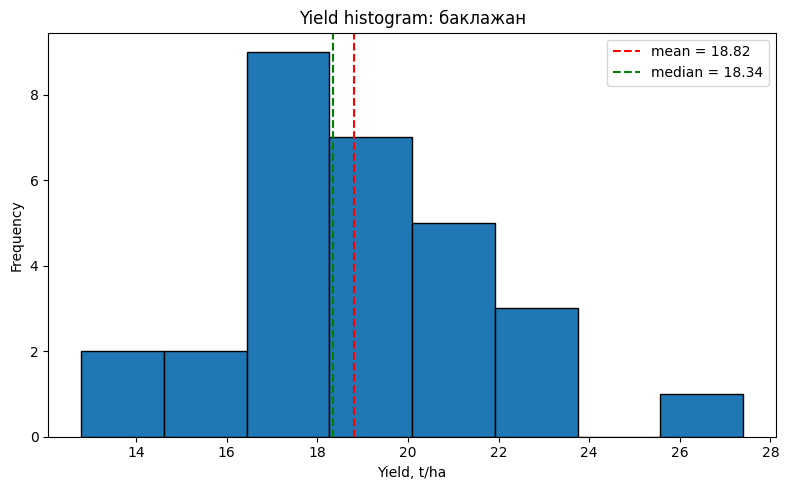

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(yld, bins=8, edgecolor="black")
plt.axvline(yld.mean(), color="red", linestyle="--", label=f"mean = {yld.mean():.2f}")
plt.axvline(yld.median(), color="green", linestyle="--", label=f"median = {yld.median():.2f}")
plt.title("Yield histogram: баклажан")
plt.xlabel("Yield, t/ha")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
top5 = (
    sample.dropna(subset=["production_t"])
    .sort_values("production_t", ascending=False)
    .head(5)
)
print("\n--- TOP-5 REGIONS BY PRODUCTION ---")
print(top5[["region_code", "region", "production_t", "harvested_area_ha", "yield_t_per_ha"]].to_string())


--- TOP-5 REGIONS BY PRODUCTION ---
    region_code                 region  production_t  harvested_area_ha  yield_t_per_ha
337         R14    Ставропольский край      61584.53             3558.8       17.304858
110         R15       Амурская область      27196.62             1406.8       19.332258
79          R08    Республика Мордовия      21594.10              788.2       27.396727
157         R28  Нижегородская область      21050.33             1045.5       20.134223
278         R12         Алтайский край      20837.66             1080.1       19.292343


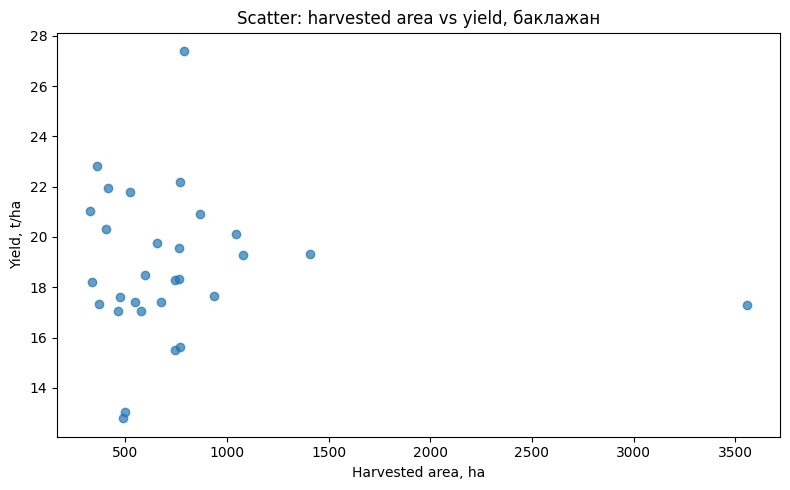

In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(sample["harvested_area_ha"], sample["yield_t_per_ha"], alpha=0.7)
plt.title("Scatter: harvested area vs yield, баклажан")
plt.xlabel("Harvested area, ha")
plt.ylabel("Yield, t/ha")
plt.tight_layout()
plt.show()